In [1]:
import pandas as pd
df_employment = pd.read_csv('./data/quasi-employment.csv')
df_groupon = pd.read_csv('./data/quasi-groupon.csv')
df_smoker = pd.read_csv('./data/quasi-smoker.csv')

## Difference-in-Difference Test

In [2]:
df_employment.shape
df_employment.info()
df_employment.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   state          384 non-null    int64  
 1   total_emp_feb  384 non-null    float64
 2   total_emp_nov  384 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 9.1 KB


,state,total_emp_feb,total_emp_nov
count,384.000000,384.000000,384.000000
mean,0.804688,21.006641,20.936198
std,0.396958,9.874065,9.183605
min,0.000000,5.000000,0.000000
25%,1.000000,14.500000,14.250000
50%,1.000000,19.500000,20.000000
75%,1.000000,24.500000,26.500000
max,1.000000,85.000000,60.500000


In [4]:
print(f'duplicates: {df_employment.duplicated().sum()}')
print(f'missing: {df_employment.isnull().sum()}')

duplicates: 18
missing: state            0
total_emp_feb    0
total_emp_nov    0
dtype: int64


In [5]:
df_employment.groupby('state').size()

state
0     75
1    309
dtype: int64

In [38]:
df_employment.head()

,state,before,after
0,0,40.50,24.0
1,0,13.75,11.5
2,0,8.50,10.5
3,0,34.00,20.0
4,0,24.00,35.5


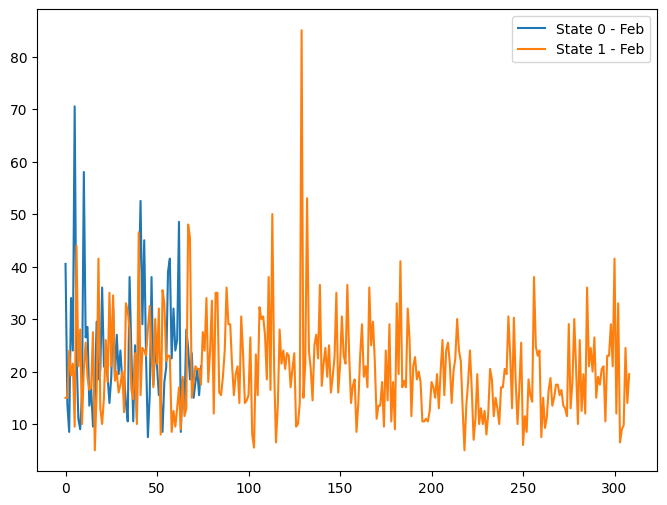

In [6]:
import matplotlib.pyplot as plt
df_emp_0 = df_employment[df_employment['state']==0].reset_index(drop=True)
df_emp_1 = df_employment[df_employment['state']==1].reset_index(drop=True)
plt.figure(figsize=(8,6))
plt.plot(df_emp_0.index, df_emp_0['total_emp_feb'], label='State 0 - Feb')
plt.plot(df_emp_1.index, df_emp_1['total_emp_feb'], label='State 1 - Feb')
plt.legend()
plt.show()

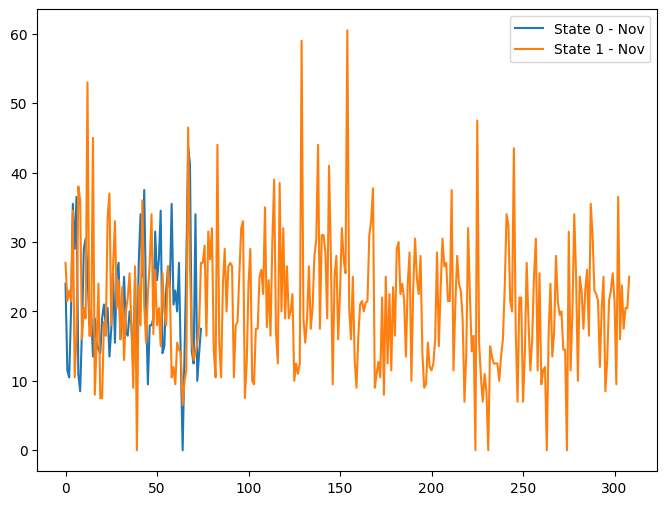

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(df_emp_0.index, df_emp_0['total_emp_nov'], label='State 0 - Nov')
plt.plot(df_emp_1.index, df_emp_1['total_emp_nov'], label='State 1 - Nov')
plt.legend()
plt.show()

In [10]:
df_employment.columns=['state','before','after']

/Users/reynafeng/Documents/Git/experiment/.venv/lib/python3.14/site-packages/seaborn/distributions.py:2125: UserWarning: `displot` is a figure-level function and does not accept the ax= parameter. You may wish to try kdeplot.
  warnings.warn(msg, UserWarning)
/Users/reynafeng/Documents/Git/experiment/.venv/lib/python3.14/site-packages/seaborn/distributions.py:2125: UserWarning: `displot` is a figure-level function and does not accept the ax= parameter. You may wish to try kdeplot.
  warnings.warn(msg, UserWarning)


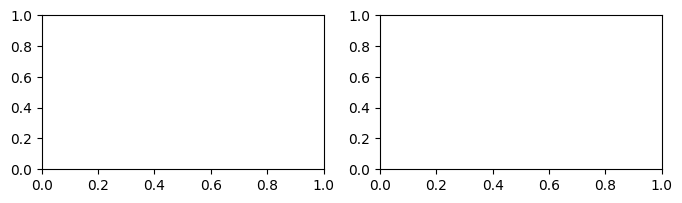

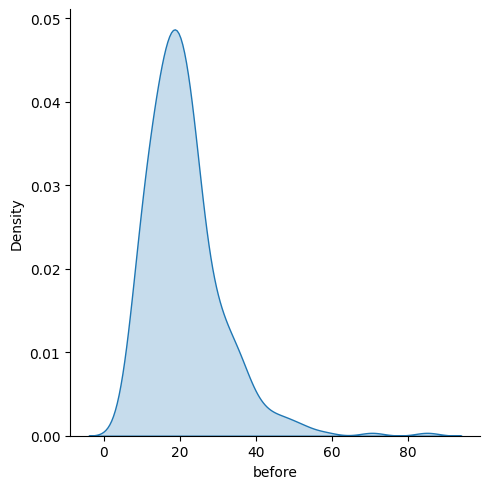

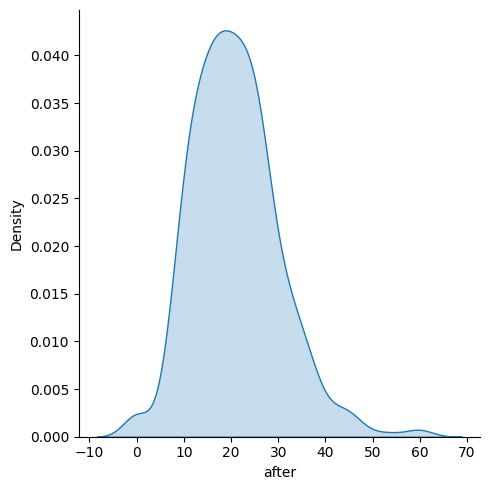

In [42]:
# employment data distribution
import seaborn as sns
fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(8,2))
axes = axes.flatten()
sns.displot(df_employment['before'],kind='kde',fill=True,ax=axes[0])
sns.displot(df_employment['after'],kind='kde',fill=True,ax=axes[1])
plt.tight_layout()
plt.show()

In [46]:
# check statistical power
from statsmodels.stats.power import TTestIndPower
power = TTestIndPower()
power.solve_power(
    effect_size=0.2,
    nobs1=75,
    ratio=309/75,
    alpha=0.05
)

np.float64(0.34107427712439303)

In [11]:
# make to long table
df_long = df_employment.melt(
    id_vars='state',
    value_vars=['before','after'],
    var_name='period',
    value_name='employment'
)
print(df_long.head())

   state  period  employment
0      0  before       40.50
1      0  before       13.75
2      0  before        8.50
3      0  before       34.00
4      0  before       24.00


In [43]:
df_long.groupby('state')['employment'].agg(['mean','std','var'])

,mean,std,var
state,,,
0,22.238333,10.382465,107.795584
1,20.663916,9.292938,86.358688


1.9066666666666667


<Axes: ylabel='employment'>

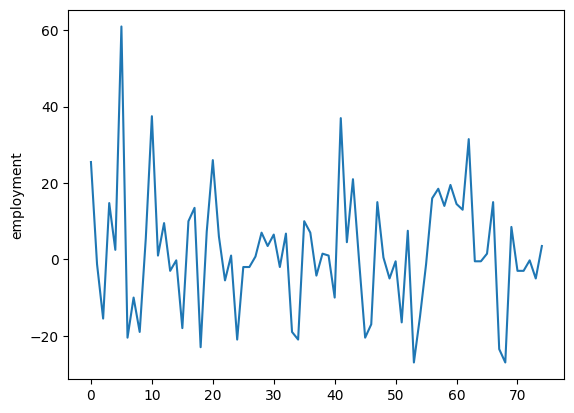

In [ ]:
# validate parallel trend for pre test data
import seaborn as sns
pre_empl_0 = df_long[(df_long['period']=='before')&(df_long['state']==0)]['employment'].reset_index()
pre_empl_1 = df_long[(df_long['period']=='before')&(df_long['state']==1)]['employment'].reset_index()
pre_empl_diff = pre_empl_0 - pre_empl_1[0:75]
print(pre_empl_diff['employment'].mean())
sns.lineplot(pre_empl_diff['employment'])

In [32]:
import statsmodels.api as smf
import numpy as np
time = np.arange(len(pre_empl_diff['employment']))
X = smf.add_constant(time)
model = smf.OLS(pre_empl_diff['employment'],X).fit()
print(f'coef: {model.params} & p value: {model.pvalues}')

coef: const    3.777193
x1      -0.050555
dtype: float64 & p value: const    0.30612
x1       0.55613
dtype: float64


In [34]:
from scipy.stats import pearsonr
corr, p = pearsonr(time, pre_empl_diff['employment'])
print(corr,p)

-0.06904417087648847 0.5561295102500324


In [35]:
import numpy as np
df_long['treated'] = (df_long['state']==1).astype(int)
df_long['post'] = (df_long['period']=='after').astype(int)
df_long['treated_post'] = df_long['treated'] * df_long['post']
# run did regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
X = df_long[['treated','post','treated_post']]
y = df_long['employment']
lr.fit(X, y)
y_pred = lr.predict(X)
residuals = y - y_pred
n = X.shape[0]
p = X.shape[1]
rss = np.sum(residuals ** 2)
sigma2 = rss / (n - p)
X_mat = np.column_stack([np.ones(len(X)),X])
cov_matrix = sigma2 * np.linalg.inv(X_mat.T @ X_mat)
se = np.sqrt(np.diag(cov_matrix))
coefs = np.concatenate([[lr.intercept_],lr.coef_])
t_stats = coefs / se
from scipy.stats import t
df_degree = n - p - 1
p_values = 2 * (1 - t.cdf(np.abs(t_stats), df=df_degree))
print("Coefficients:", coefs, "Standard Errors:", se, "T-stats:", t_stats, "P-values:", p_values)

Coefficients: [23.38       -2.94941748 -2.28333333  2.75      ] Standard Errors: [1.09755677 1.22352645 1.55217966 1.73032771] T-stats: [21.30185947 -2.41058742 -1.47104964  1.58929432] P-values: [0.         0.01616203 0.14168943 0.11240767]


1. treated coef is significant, showing baseline difference is strong between groups
2. post has no strong over time trend across all groups, meaning overall market level did not significantly change
3. treated_post is not statistically significant, could mean (true effect small, sample size small, high variance, poor control group, parallel trend violated)
4. before DiD, need do parallet trend assumption

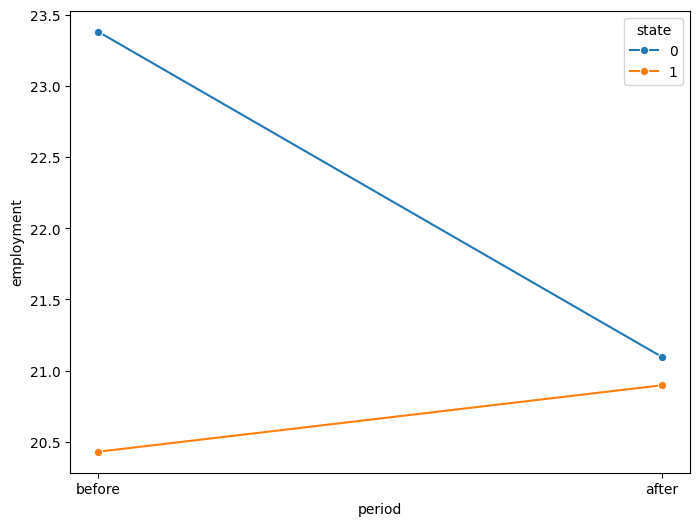

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
plot_df = df_long.groupby(['post','state'])['employment'].mean().reset_index()
plot_df['period'] = plot_df['post'].map({
    0: 'before',
    1: 'after'
})
plt.figure(figsize=(8,6))
sns.lineplot(data=plot_df, x='period', y='employment', hue='state', marker='o')
plt.show()

In Difference-in-Differences models, a low R² is not necessarily problematic because the objective is causal identification rather than predictive accuracy. What matters more is whether the treatment interaction coefficient is statistically significant, economically meaningful, and supported by valid assumptions such as parallel trends.

In [36]:
# confidence interval, use when p_value is not too low, CI can give a range
t_crit = t.ppf(1 - 0.05/2, df=n-p-1)
lower = coefs - t_crit * se
upper = coefs + t_crit * se
print("95% Confidence Intervals:")
for i in range(len(coefs)):
    print(f"Coef {i}: [{lower[i]:.4f}, {upper[i]:.4f}]")

95% Confidence Intervals:
Coef 0: [21.2254, 25.5346]
Coef 1: [-5.3513, -0.5475]
Coef 2: [-5.3304, 0.7637]
Coef 3: [-0.6468, 6.1468]


In [45]:
# cohen'd
change_0 = df_employment[df_employment['state']==0]['after'] - df_employment[df_employment['state']==0]['before']
change_1 = df_employment[df_employment['state']==1]['after'] - df_employment[df_employment['state']==1]['before']
mean_diff = (change_0.mean()-change_1.mean())
pooled_std = np.sqrt(
    (change_0.var(ddof=1)+change_1.var(ddof=1))/2
)
d = mean_diff/pooled_std
print(f'cohen_d: {d}')

cohen_d: -0.28270940726384197


## Propensity Score: predict receiving treatment probability

In [47]:
df_groupon.shape
df_groupon.info()
df_groupon.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 710 entries, 0 to 709
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   deal_id          710 non-null    object
 1   start_date       710 non-null    object
 2   min_req          710 non-null    int64 
 3   treatment        710 non-null    int64 
 4   prom_length      710 non-null    int64 
 5   price            710 non-null    int64 
 6   discount_pct     710 non-null    int64 
 7   coupon_duration  710 non-null    int64 
 8   featured         710 non-null    int64 
 9   limited_supply   710 non-null    int64 
 10  fb_likes         710 non-null    int64 
 11  quantity_sold    710 non-null    int64 
 12  revenue          710 non-null    int64 
dtypes: int64(11), object(2)
memory usage: 72.2+ KB


,min_req,treatment,prom_length,price,discount_pct,coupon_duration,featured,limited_supply,fb_likes,quantity_sold,revenue
count,710.000000,710.000000,710.000000,710.000000,710.000000,710.00000,710.000000,710.000000,710.000000,710.000000,710.000000
mean,8.759155,0.304225,3.678873,35.300000,53.061972,106.86338,0.116901,0.829577,88.669014,386.652113,10642.701408
std,27.880963,0.460403,1.323959,36.356624,8.190716,128.15513,0.321529,0.376269,150.282551,663.358446,18131.366995
min,1.000000,0.000000,2.000000,5.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,3.000000,15.000000,50.000000,11.00000,0.000000,1.000000,17.000000,70.000000,1565.000000
50%,1.000000,0.000000,3.000000,24.000000,51.000000,75.00000,0.000000,1.000000,40.500000,190.000000,5000.000000
75%,5.000000,1.000000,4.000000,39.000000,56.000000,185.00000,0.000000,1.000000,99.000000,480.000000,12450.000000
max,300.000000,1.000000,9.000000,299.000000,85.000000,1812.00000,1.000000,1.000000,1596.000000,5000.000000,210000.000000


In [49]:
df_groupon.duplicated().sum()

np.int64(0)

In [ ]:
# check groups balance
df_groupon['treatment'].value_counts()

treatment
0    494
1    216
Name: count, dtype: int64

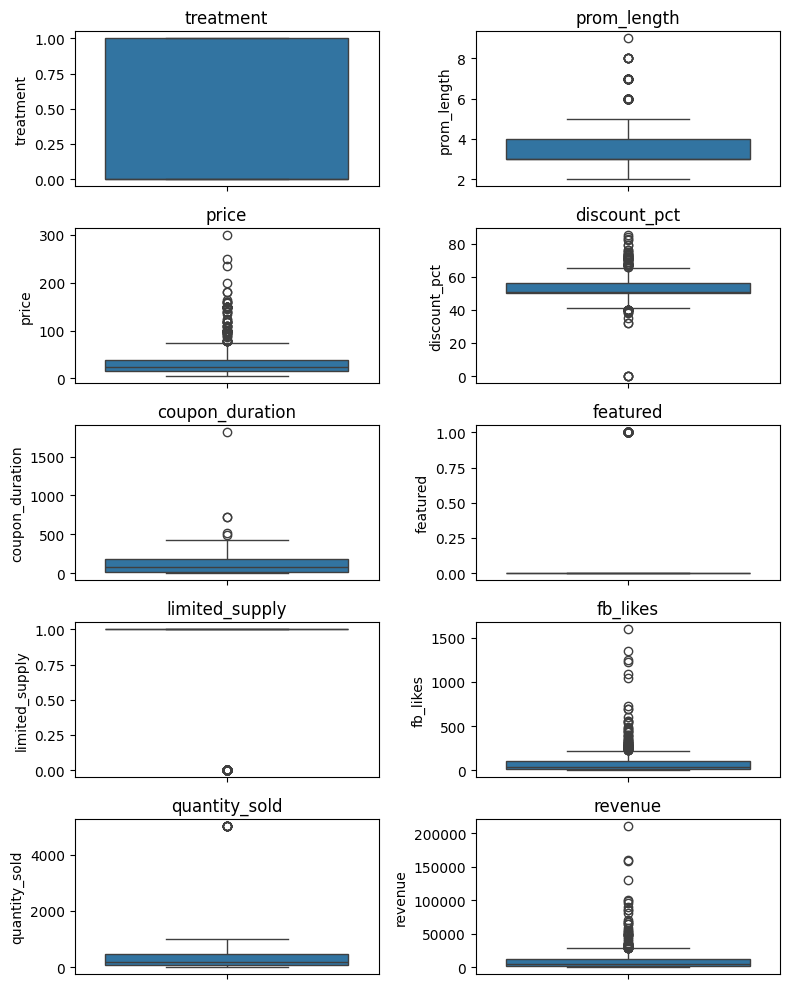

In [74]:
import math
num_cols = df_groupon.select_dtypes(include='number').columns
target_cols = ['revenue','quantity_sold']
exclude_cat_cols = ['deal_id']
exclude_num_cols = ['min_req']
treatment_cols = 'treatment'
num_cols = num_cols.drop(exclude_num_cols)
n_cols = 2
n_rows = math.ceil(len(num_cols)/n_cols)
fig, axes = plt.subplots(nrows=n_rows,ncols=n_cols,figsize=(8,2*n_rows))
axes = axes.flatten()
for i,col in enumerate(num_cols):
    sns.boxplot(data=df_groupon[col],ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
# check skewness
from scipy.stats import skew
for col in num_cols:
    print(col, skew(df_groupon[col]))
# <1 mild, >2 highly skewed
# price, coupon_duration, featured, fb_likes are skewed

treatment 0.8510487651126634
prom_length 1.0270945779043896
price 2.7811350164858073
discount_pct -0.6286751122954012
coupon_duration 4.240030549526751
featured 2.384657892236153
limited_supply -1.7530549142063374
fb_likes 5.107066039625901
quantity_sold 5.2731061825667656
revenue 5.145914048332179


In [ ]:
df_groupon.groupby('treatment')[num_cols].agg(['mean','std']).T #transpose
# price, coupon_duration, fb_like might be confounder

treatment                        0             1
treatment       mean      0.000000      1.000000
                std       0.000000      0.000000
prom_length     mean      3.809717      3.379630
                std       1.310059      1.309838
price           mean     37.870445     29.421296
                std      37.759990     32.242011
discount_pct    mean     52.973684     53.263889
                std       8.710659      6.869534
coupon_duration mean     95.941296    131.842593
                std     127.455209    126.528288
featured        mean      0.105263      0.143519
                std       0.307203      0.351415
limited_supply  mean      0.852227      0.777778
                std       0.355235      0.416705
fb_likes        mean     77.941296    113.203704
                std     135.724674    177.110359
quantity_sold   mean    333.002024    509.351852
                std     569.099882    828.693169
revenue         mean   9720.987854  12750.694444
                std   14953.130216  23769.128111

In [76]:
df_groupon.groupby('treatment')[num_cols].nunique().T

treatment,0,1
treatment,1,1
prom_length,8,7
price,77,51
discount_pct,44,35
coupon_duration,171,101
featured,2,2
limited_supply,2,2
fb_likes,180,133
quantity_sold,93,66
revenue,321,166


In [ ]:
# confounder
import statsmodels.formula.api as smf
model = smf.logit('treatment ~ prom_length+price+discount_pct+coupon_duration+featured+limited_supply+fb_likes',data=df_groupon).fit()
print(model.summary())
model = smf.ols('revenue ~ prom_length+price+discount_pct+coupon_duration+featured+limited_supply+fb_likes',data=df_groupon).fit()
print(model.summary())
# confounder: prom_length, price, fb_likes

Optimization terminated successfully.
         Current function value: 0.568546
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              treatment   No. Observations:                  710
Model:                          Logit   Df Residuals:                      702
Method:                           MLE   Df Model:                            7
Date:                Mon, 01 Jun 2026   Pseudo R-squ.:                 0.07464
Time:                        09:42:36   Log-Likelihood:                -403.67
converged:                       True   LL-Null:                       -436.23
Covariance Type:            nonrobust   LLR p-value:                 1.425e-11
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.9673      0.684      1.414      0.157      -0.374       2.308
prom_length   

<Axes: xlabel='start_date'>

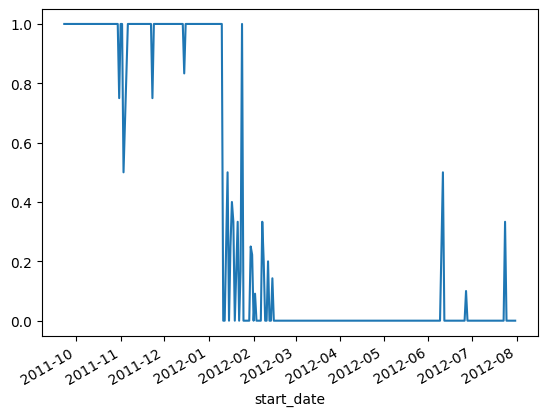

In [ ]:
# check seasonality
df_groupon['start_date']=pd.to_datetime(df_groupon['start_date'])
df_groupon.groupby('start_date')['treatment'].mean().plot(kind='line')

<Axes: >

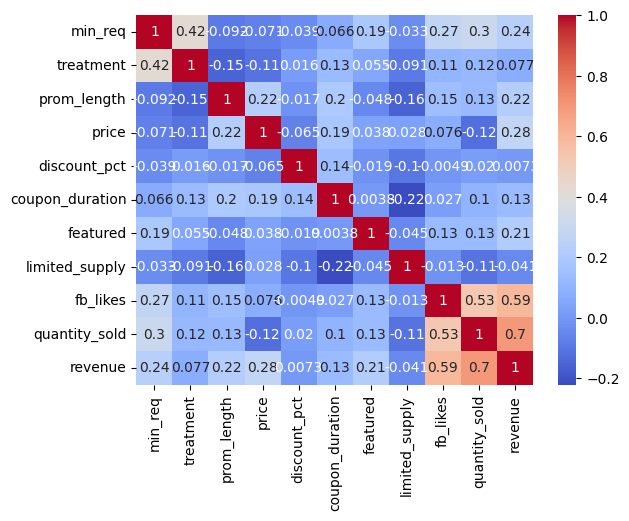

In [ ]:
# multicollinearity
sns.heatmap(df_groupon[num_cols].corr(), annot=True,cmap='coolwarm')

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_df = pd.DataFrame({
    'feature': num_cols.drop(target_cols),
    'VIF': [variance_inflation_factor(df_groupon[num_cols.drop(target_cols)].values, i) for i in range(len(num_cols.drop(target_cols)))]
})
vif_df
# prom_length, discount_pct, limited_supply have high VIF

,feature,VIF
0,min_req,1.478878
1,treatment,1.797338
2,prom_length,8.465336
3,price,2.152549
4,discount_pct,12.621277
5,coupon_duration,1.979097
6,featured,1.187459
7,limited_supply,5.303500
8,fb_likes,1.527272


<Axes: >

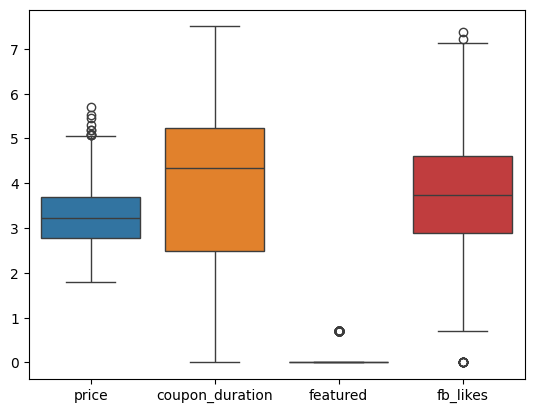

In [81]:
df = df_groupon.copy()
update_cols = ['price', 'coupon_duration', 'featured', 'fb_likes']
for col in update_cols:
    df[col] = np.log1p(df[col])
sns.boxplot(data=df[[col for col in update_cols]])

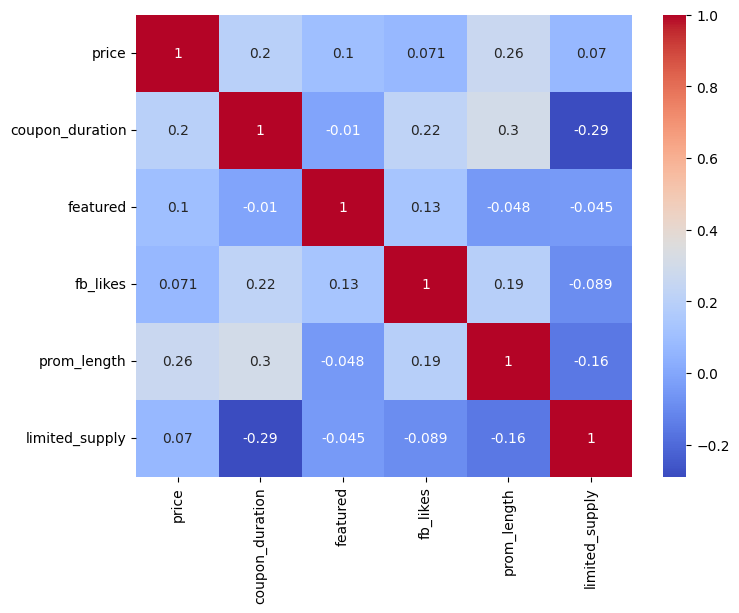

In [83]:
feature_cols = [col for col in update_cols] + ['prom_length','limited_supply']
corr = df[feature_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()
# >0.7 moderat, >0.9 serious

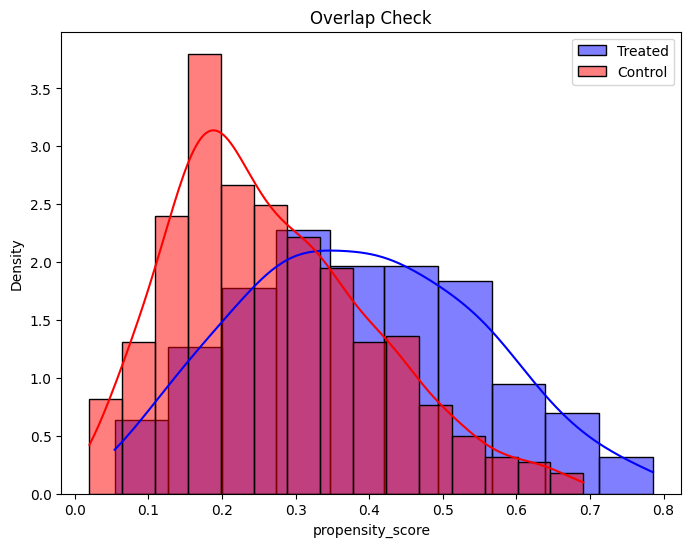

In [86]:
# train model
from sklearn.linear_model import LogisticRegression
X = df[feature_cols]
y = df['treatment']
ps_model = LogisticRegression()
ps_model.fit(X,y)
df['propensity_score'] = ps_model.predict_proba(X)[:,1]
# check overlap
treated = df[(df['treatment']==1)]
control = df[(df['treatment']==0)]
plt.figure(figsize=(8,6))
sns.histplot(treated['propensity_score'], color='blue', label='Treated', kde=True, stat='density')  
sns.histplot(control['propensity_score'], color='red', label='Control', kde=True, stat='density')
plt.title('Overlap Check')
plt.legend()
plt.show()

this chart is showing treated near 1 control near 0: matching unreliable

In [88]:
from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])
distances, indices = nn.kneighbors(treated[['propensity_score']])
matched_control = control.iloc[indices.flatten()].reset_index(drop=True)
matched_df = pd.concat([treated.reset_index(drop=True), matched_control], ignore_index=True)
df_groupon.groupby('treatment')[feature_cols].mean()

,price,coupon_duration,featured,fb_likes,prom_length,limited_supply
treatment,,,,,,
0,37.870445,95.941296,0.105263,77.941296,3.809717,0.852227
1,29.421296,131.842593,0.143519,113.203704,3.379630,0.777778


In [89]:
matched_df.groupby('treatment')[feature_cols].mean()

,price,coupon_duration,featured,fb_likes,prom_length,limited_supply
treatment,,,,,,
0,3.141205,4.316191,0.057762,4.185529,3.601852,0.731481
1,3.124606,4.130177,0.099479,4.066291,3.379630,0.777778


In [91]:
# standardize mean difference
smd_results = []
for col in feature_cols:
    mean_t = matched_df[matched_df['treatment']==1][col].mean()
    mean_c = matched_df[matched_df['treatment']==0][col].mean()
    var_t = matched_df[matched_df['treatment']==1][col].var(ddof=1)
    var_c = matched_df[matched_df['treatment']==0][col].var(ddof=1)
    pooled_std = np.sqrt((var_t + var_c) / 2)
    smd = (mean_t - mean_c) / pooled_std
    smd_results.append({'feature': col, 'abs_smd': abs(smd)})
smd_df = pd.DataFrame(smd_results)
print(smd_df.sort_values('abs_smd',ascending=False))

           feature   abs_smd
4      prom_length  0.191567
2         featured  0.190210
1  coupon_duration  0.132071
5   limited_supply  0.107495
3         fb_likes  0.098429
0            price  0.023362


In [90]:
matched_df['treatment'].value_counts()

treatment
1    216
0    216
Name: count, dtype: int64

In [92]:
# validate balance with standardized mean difference
def smd(df, treatment_col, feature):
    treated = matched_df[matched_df[treatment_col]==1][feature]
    control = matched_df[matched_df[treatment_col]==0][feature]
    return (treated.mean() - control.mean()) / np.sqrt((treated.var() + control.var()) / 2)

for col in feature_cols:
    print(f"SMD for {col}: {smd(matched_df, 'treatment', col):.2f}")
# <0.2, excellent, <0.2 acceptable, >0.25 imbalance concern

SMD for price: -0.02
SMD for coupon_duration: -0.13
SMD for featured: 0.19
SMD for fb_likes: -0.10
SMD for prom_length: -0.19
SMD for limited_supply: 0.11


<Axes: xlabel='fb_likes_scaled', ylabel='Count'>

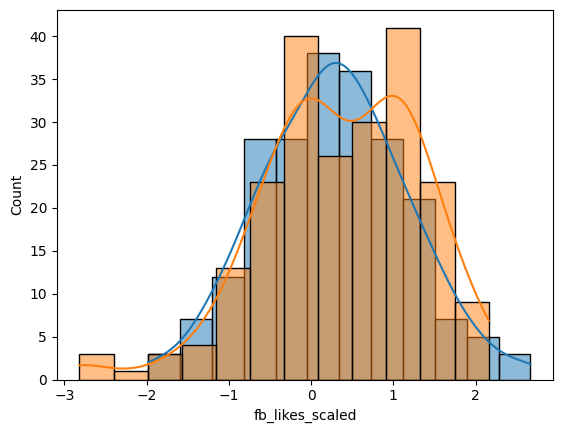

In [93]:
sns.histplot(matched_df[matched_df['treatment']==1]['fb_likes_scaled'], kde=True)
sns.histplot(matched_df[matched_df['treatment']==0]['fb_likes_scaled'], kde=True)

<Axes: xlabel='revenue_scale', ylabel='Density'>

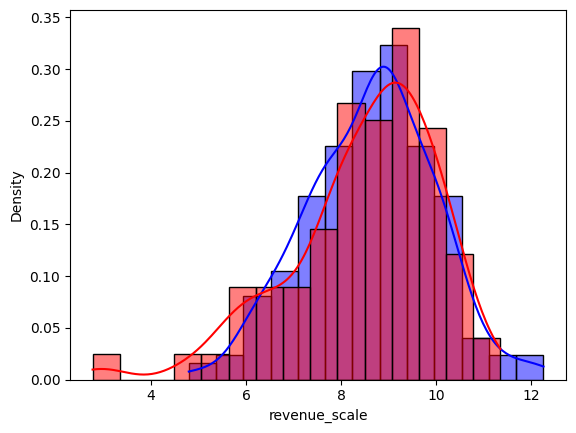

In [99]:
matched_df['revenue_scale'] = np.log1p(matched_df['revenue'])
sns.histplot(matched_df[matched_df['treatment']==1]['revenue_scale'], color='blue', label='Treated', kde=True, stat='density')
sns.histplot(matched_df[matched_df['treatment']==0]['revenue_scale'], color='red', label='Control', kde=True, stat='density')

In [101]:
# since scaled metrics are approximately normal, use t test
from scipy.stats import ttest_ind
treated_outcome = matched_df[
    matched_df["treatment"] == 1
]["revenue_scale"]
control_outcome = matched_df[
    matched_df["treatment"] == 0
]["revenue_scale"]
t_stat, p_value = ttest_ind(
    treated_outcome, control_outcome, equal_var=False
)
print(p_value)

0.3537574918155042


## PSM / Stratification

In [102]:
df_smoker.shape
df_smoker.isnull().sum()
df_smoker.info()
df_smoker.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   smoker     10000 non-null  int64
 1   treatment  10000 non-null  int64
 2   outcome    10000 non-null  int64
dtypes: int64(3)
memory usage: 234.5 KB


,smoker,treatment,outcome
count,10000.000000,10000.000000,10000.000000
mean,0.302500,0.300400,0.266700
std,0.459364,0.458455,0.442256
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


In [103]:
# check group balance
df_smoker['treatment'].value_counts()

treatment
0    6996
1    3004
Name: count, dtype: int64

In [104]:
# check categorical balance
pd.crosstab(df_smoker['treatment'],df_smoker['smoker'])

smoker,0,1
treatment,,
0,5646,1350
1,1329,1675


In [108]:
pd.crosstab(df_smoker['outcome'],df_smoker['treatment'])

treatment,0,1
outcome,,
0,5351,1982
1,1645,1022


In [ ]:
# PSM 
psm_model = smf.logit('treatment ~ smoker',data=df_smoker).fit()
print(psm_model.summary())
# smoker has effect on treatment assignment

Optimization terminated successfully.
         Current function value: 0.547611
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              treatment   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9998
Method:                           MLE   Df Model:                            1
Date:                Mon, 01 Jun 2026   Pseudo R-squ.:                  0.1040
Time:                        12:38:30   Log-Likelihood:                -5476.1
converged:                       True   LL-Null:                       -6112.0
Covariance Type:            nonrobust   LLR p-value:                1.497e-278
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4465      0.030    -47.444      0.000      -1.506      -1.387
smoker         1.6622      0.

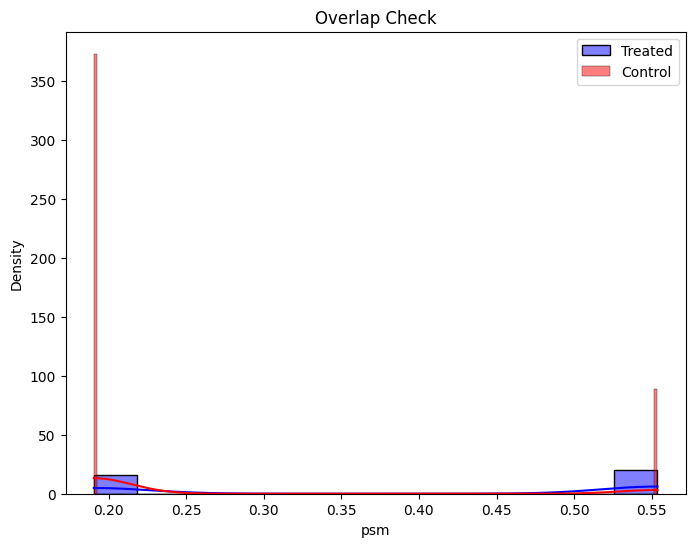

In [111]:
df = df_smoker.copy()
df['psm'] = psm_model.predict(df)
treated = df[(df['treatment']==1)]
control = df[(df['treatment']==0)]
plt.figure(figsize=(8,6))
sns.histplot(treated['psm'], color='blue', label='Treated', kde=True, stat='density')  
sns.histplot(control['psm'], color='red', label='Control', kde=True, stat='density')
plt.title('Overlap Check')
plt.legend()
plt.show()

In [113]:
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['psm']])
distances, indices = nn.kneighbors(treated[['psm']])
matched_control = control.iloc[indices.flatten()].reset_index(drop=True)
matched_df = pd.concat([treated.reset_index(drop=True), matched_control], ignore_index=True)
df_smoker.groupby('treatment')['smoker'].mean()

treatment
0    0.192967
1    0.557590
Name: smoker, dtype: float64

In [115]:
matched_df.groupby('treatment')['smoker'].mean()

treatment
0    0.55759
1    0.55759
Name: smoker, dtype: float64

In [116]:
matched_df['treatment'].value_counts()

treatment
1    3004
0    3004
Name: count, dtype: int64

In [117]:
matched_df.groupby('treatment')['outcome'].agg(['mean','std'])

,mean,std
treatment,,
0,0.557590,0.496755
1,0.340213,0.473860


In [118]:
from statsmodels.stats.proportion import proportions_ztest
successes = [matched_df[matched_df['treatment']==1]['outcome'].sum(), matched_df[matched_df['treatment']==0]['outcome'].sum()]
nobs = [matched_df[matched_df['treatment']==1].shape[0], matched_df[matched_df['treatment']==0].shape[0]]
z_stat, p_value = proportions_ztest(successes, nobs)
print(f"Z-statistic: {z_stat:.4f}, P-value: {p_value:.4f}")

Z-statistic: -16.9378, P-value: 0.0000
